# WindSight — Exploratory Data Analysis

This notebook provides a comprehensive visual overview of the four wind-farm datasets used in the WindFM project:

| Dataset | Role | Location |
|---------|------|----------|
| **SDWPF** | Train | Gansu, China |
| **Kelmarsh** | Eval | Northamptonshire, UK |
| **Penmanshiel** | Eval | Scottish Borders, UK |
| **Hill of Towie** | Eval | Aberdeenshire, UK |


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 15,
})

DATA_ROOT = Path("../data")

DATASETS = {
    "SDWPF":          DATA_ROOT / "sdwpf/processed/train.parquet",
    "Kelmarsh":       DATA_ROOT / "kelmarsh/processed/eval.parquet",
    "Penmanshiel":    DATA_ROOT / "penmanshiel/processed/eval.parquet",
    "Hill of Towie":  DATA_ROOT / "hill_of_towie/processed/eval.parquet",
}

COLORS = {
    "SDWPF":         "#1f77b4",
    "Kelmarsh":      "#ff7f0e",
    "Penmanshiel":   "#2ca02c",
    "Hill of Towie": "#d62728",
}

LOCATIONS = {
    "SDWPF":         "Gansu, China",
    "Kelmarsh":      "Northamptonshire, UK",
    "Penmanshiel":   "Scottish Borders, UK",
    "Hill of Towie": "Aberdeenshire, UK",
}

FEATURES = ["wind_speed", "wind_direction", "power", "density", "temperature", "pressure"]
FEATURE_LABELS = {
    "wind_speed":      "Wind Speed (m/s)",
    "wind_direction":  "Wind Direction (°)",
    "power":           "Power (MW)",
    "density":         "Air Density (kg/m³)",
    "temperature":     "Temperature (K)",
    "pressure":        "Pressure (Pa)",
}

# Load all datasets
data = {}
for name, path in DATASETS.items():
    df = pd.read_parquet(path)
    df["time"] = pd.to_datetime(df["time"])
    data[name] = df
    print(f"Loaded {name}: {len(df):,} rows, {df['TurbID'].nunique()} turbines")


Loaded SDWPF: 1,779,125 rows, 134 turbines
Loaded Kelmarsh: 265,134 rows, 6 turbines
Loaded Penmanshiel: 74,533 rows, 9 turbines
Loaded Hill of Towie: 183,650 rows, 21 turbines


## 1. Dataset Summary Table

In [2]:
summary_rows = []
for name, df in data.items():
    summary_rows.append({
        "Dataset":    name,
        "Location":   LOCATIONS[name],
        "Rows":       f"{len(df):,}",
        "Turbines":   df["TurbID"].nunique(),
        "Start":      df["time"].min().strftime("%Y-%m-%d"),
        "End":        df["time"].max().strftime("%Y-%m-%d"),
        "Duration (days)": (df["time"].max() - df["time"].min()).days,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.hide(axis="index").set_caption("Dataset Overview"))


Dataset,Location,Rows,Turbines,Start,End,Duration (days)
SDWPF,"Gansu, China","1,779,125",134,2020-01-03,2021-08-31,606
Kelmarsh,"Northamptonshire, UK","265,134",6,2016-05-03,2021-06-16,1869
Penmanshiel,"Scottish Borders, UK","74,533",9,2020-01-01,2020-12-31,365
Hill of Towie,"Aberdeenshire, UK","183,650",21,2020-01-01,2021-01-01,366


## 2. Power Curves

Scatter of power output vs. wind speed for every turbine in each dataset. The characteristic cubic rise followed by a rated-power plateau is clearly visible.

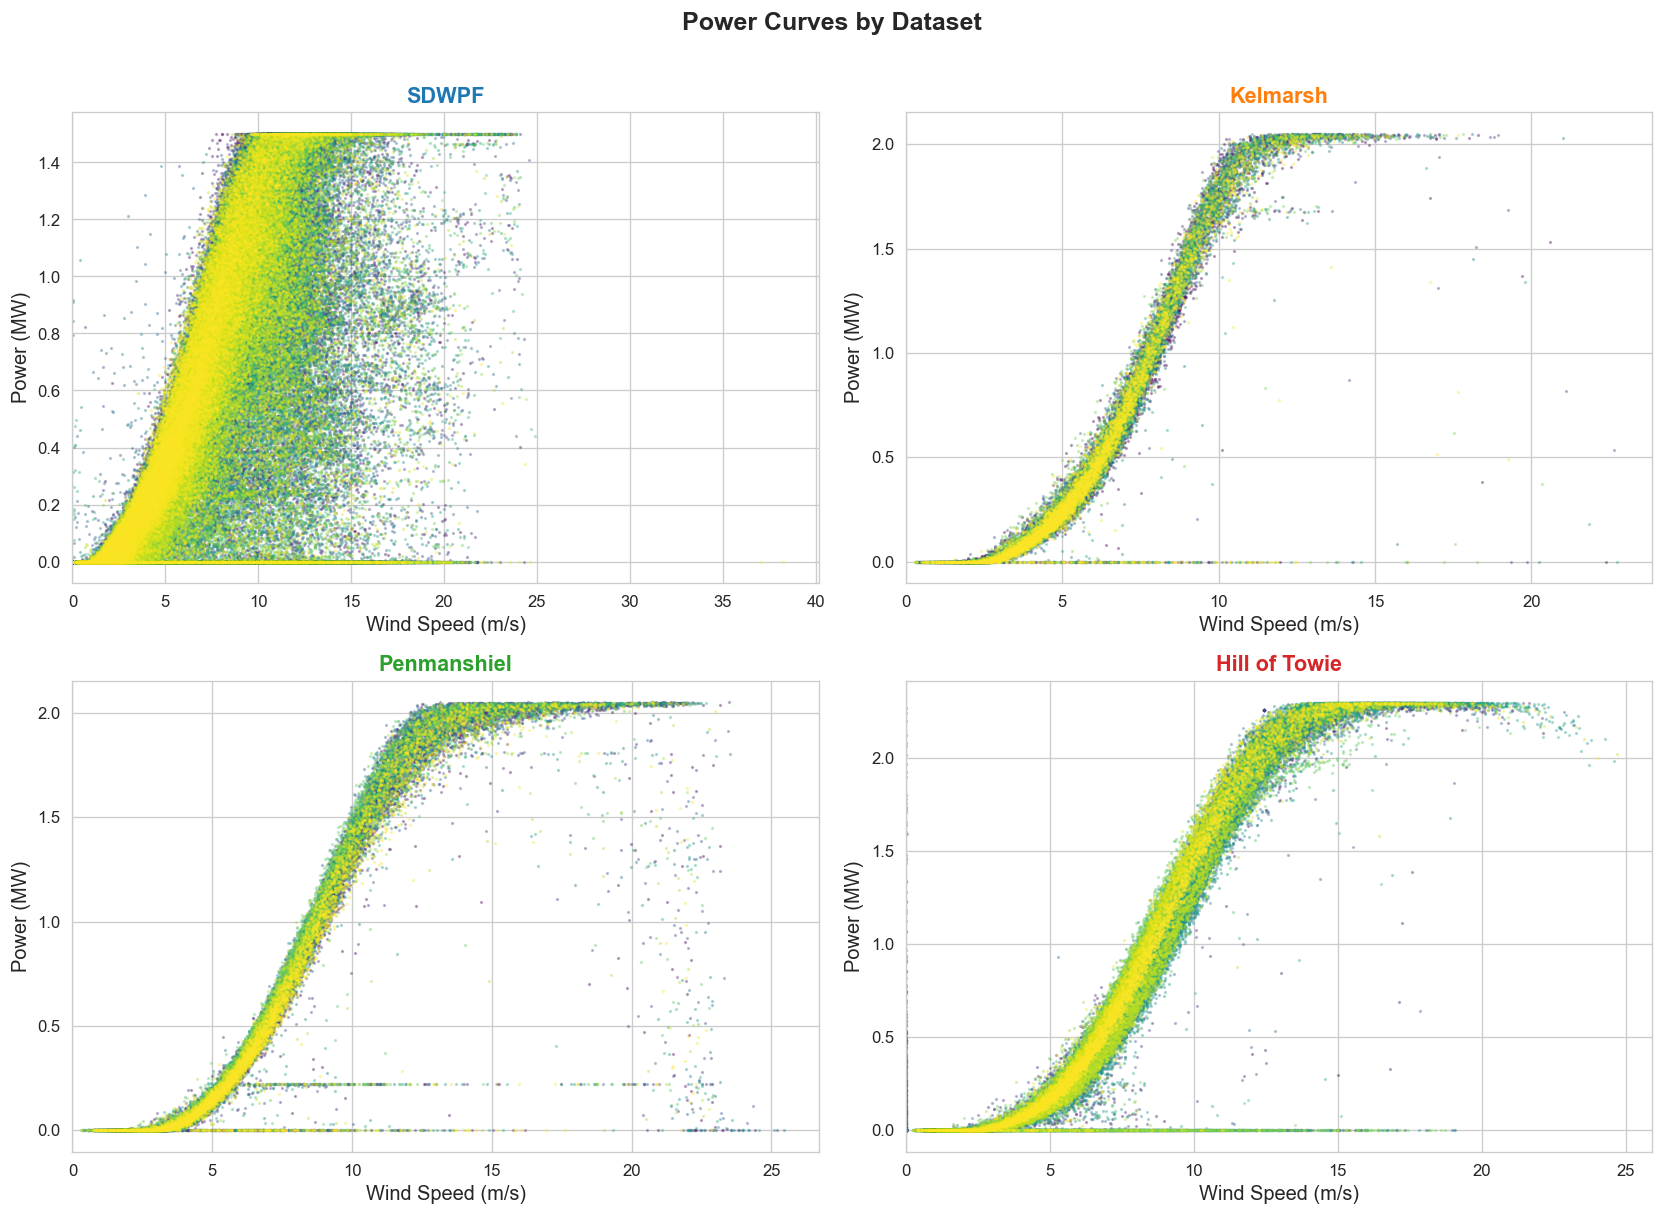

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.ravel()

for idx, (name, df) in enumerate(data.items()):
    ax = axes[idx]
    turb_ids = sorted(df["TurbID"].unique())
    cmap = plt.cm.viridis(np.linspace(0, 1, len(turb_ids)))

    for i, tid in enumerate(turb_ids):
        sub = df[df["TurbID"] == tid]
        # Subsample for performance (max 5000 pts per turbine)
        if len(sub) > 5000:
            sub = sub.sample(5000, random_state=42)
        ax.scatter(
            sub["wind_speed"], sub["power"],
            s=1, alpha=0.3, color=cmap[i], rasterized=True,
        )

    ax.set_title(name, fontweight="bold", color=COLORS[name])
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Power (MW)")
    ax.set_xlim(left=0)

fig.suptitle("Power Curves by Dataset", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 3. Wind Roses

Polar histograms of wind direction reveal the prevailing wind patterns at each site.

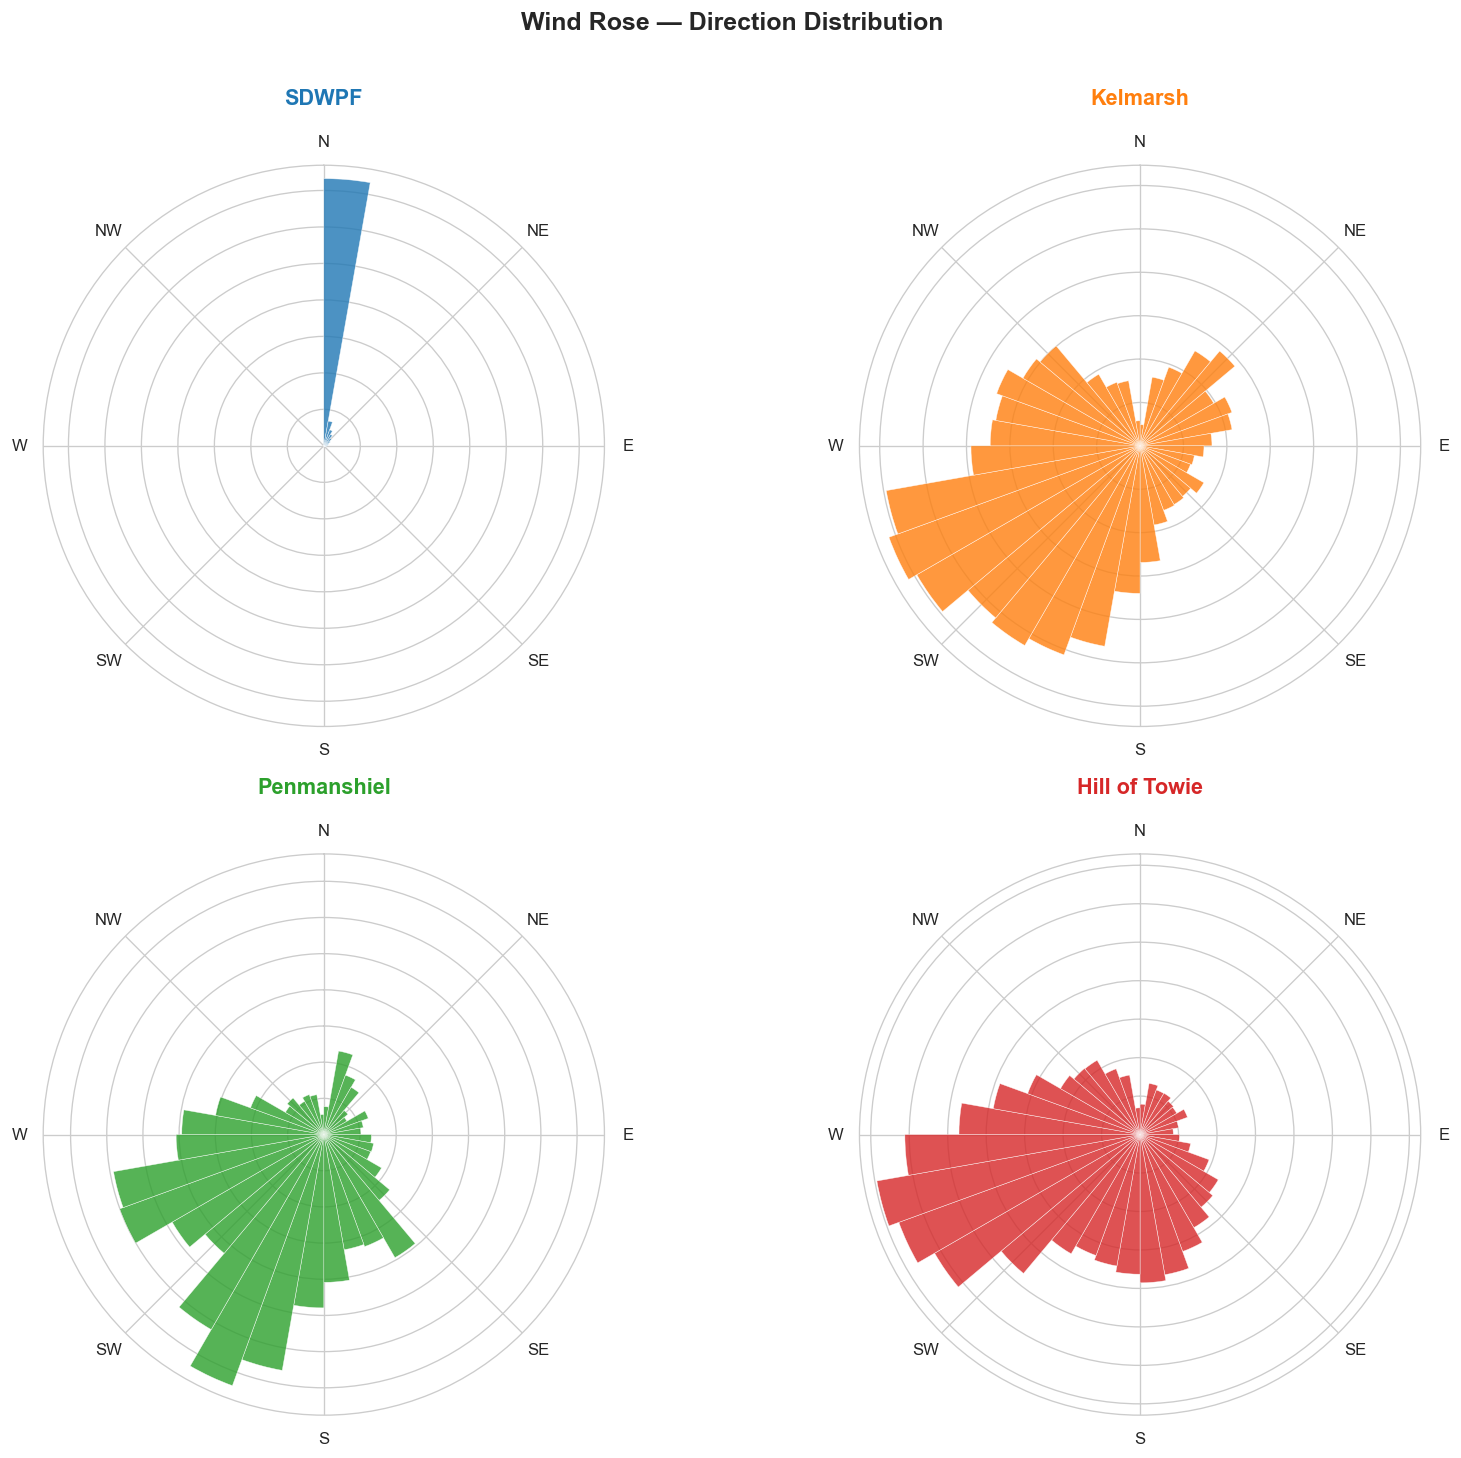

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={"projection": "polar"})
axes = axes.ravel()

n_bins = 36  # 10° bins

for idx, (name, df) in enumerate(data.items()):
    ax = axes[idx]
    wd = df["wind_direction"].dropna()

    # Bin edges in radians
    bin_edges = np.linspace(0, 2 * np.pi, n_bins + 1)
    wd_rad = np.deg2rad(wd)
    counts, _ = np.histogram(wd_rad, bins=bin_edges)
    counts = counts / counts.sum()  # normalize to fraction

    # Center of each bin
    theta = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = 2 * np.pi / n_bins

    bars = ax.bar(
        theta, counts, width=width,
        color=COLORS[name], edgecolor="white", linewidth=0.3, alpha=0.8,
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(name, fontweight="bold", pad=18, color=COLORS[name])
    ax.set_yticklabels([])  # cleaner look
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])

fig.suptitle("Wind Rose — Direction Distribution", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 4. Feature Distributions

Overlaid histograms for every feature, one colour per dataset. Distribution shift between the Chinese (SDWPF) and UK sites is evident, especially in temperature and pressure.

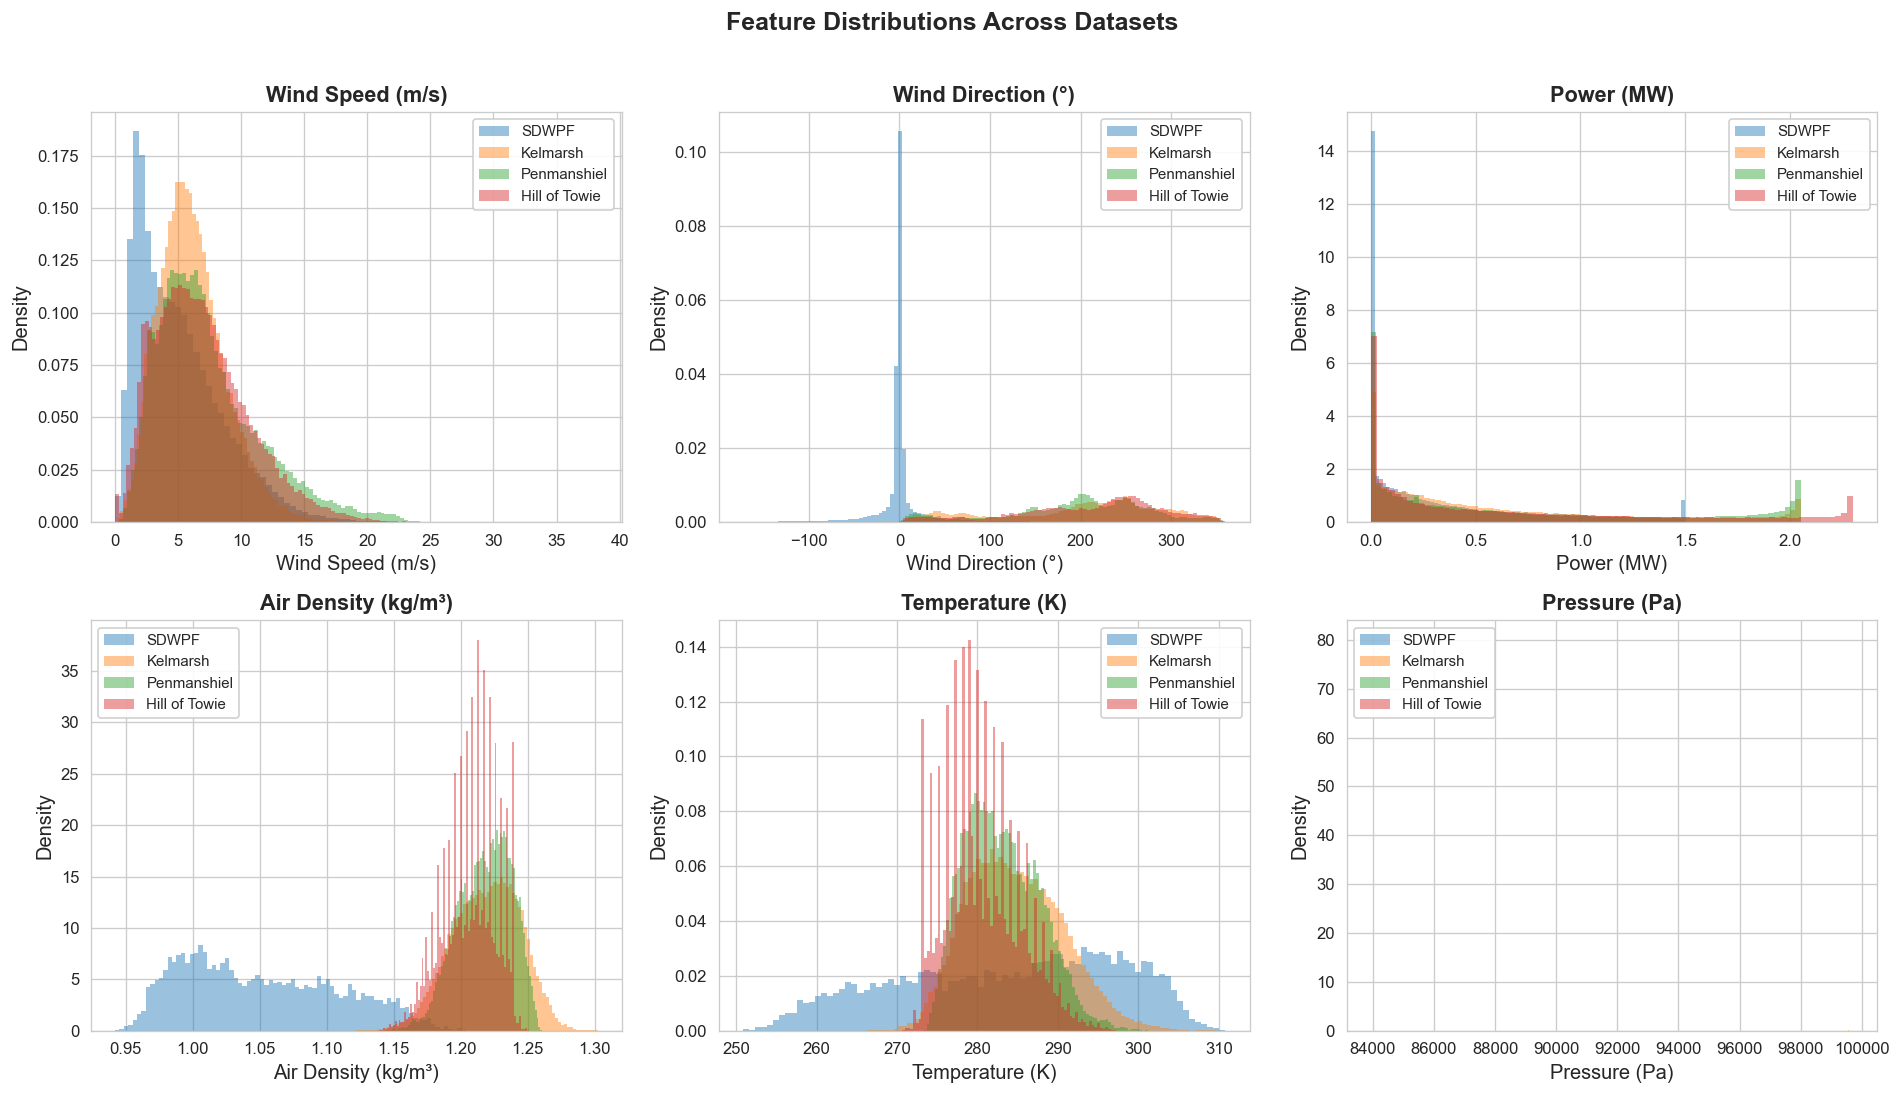

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for name, df in data.items():
        vals = df[feat].dropna()
        # Cap at 100k samples for speed
        if len(vals) > 100_000:
            vals = vals.sample(100_000, random_state=42)
        ax.hist(
            vals, bins=80, density=True,
            color=COLORS[name], alpha=0.45, label=name,
            edgecolor="none",
        )
    ax.set_xlabel(FEATURE_LABELS[feat])
    ax.set_ylabel("Density")
    ax.set_title(FEATURE_LABELS[feat], fontweight="bold")
    ax.legend(frameon=True, framealpha=0.9)

fig.suptitle("Feature Distributions Across Datasets", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 5. Missing / Zero-Value Heatmap

Percentage of NaN **or** zero values per feature per dataset. Zero power readings may indicate curtailment or sensor drop-outs.

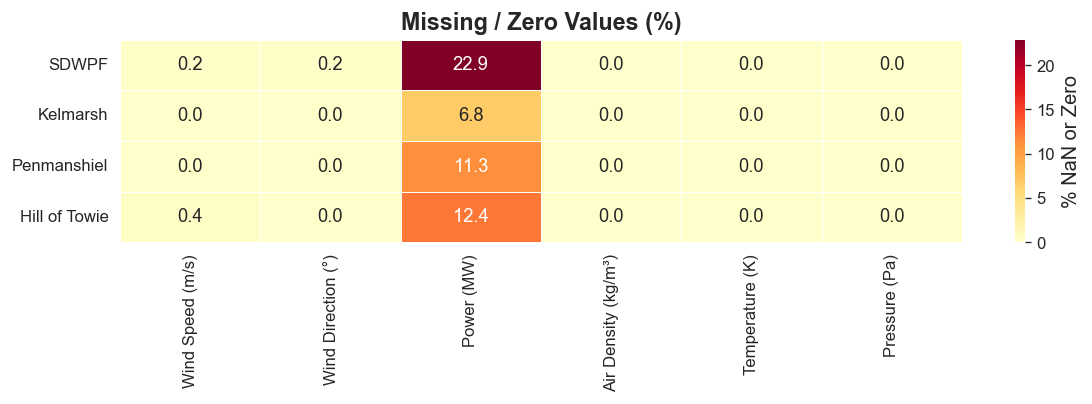

In [6]:
missing_rows = []
for name, df in data.items():
    row = {"Dataset": name}
    for feat in FEATURES:
        n_nan = df[feat].isna().sum()
        n_zero = (df[feat] == 0).sum()
        pct = 100.0 * (n_nan + n_zero) / len(df)
        row[FEATURE_LABELS[feat]] = round(pct, 2)
    missing_rows.append(row)

missing_df = pd.DataFrame(missing_rows).set_index("Dataset")

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(
    missing_df, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, cbar_kws={"label": "% NaN or Zero"},
    ax=ax,
)
ax.set_title("Missing / Zero Values (%)", fontweight="bold", fontsize=14)
ax.set_ylabel("")
fig.tight_layout()
plt.show()


## 6. Temporal Patterns

**Left:** Average power output by hour of day (diurnal cycle) across all datasets.  
**Right:** Average power output by month (seasonal cycle) for SDWPF, the only dataset spanning a full year.

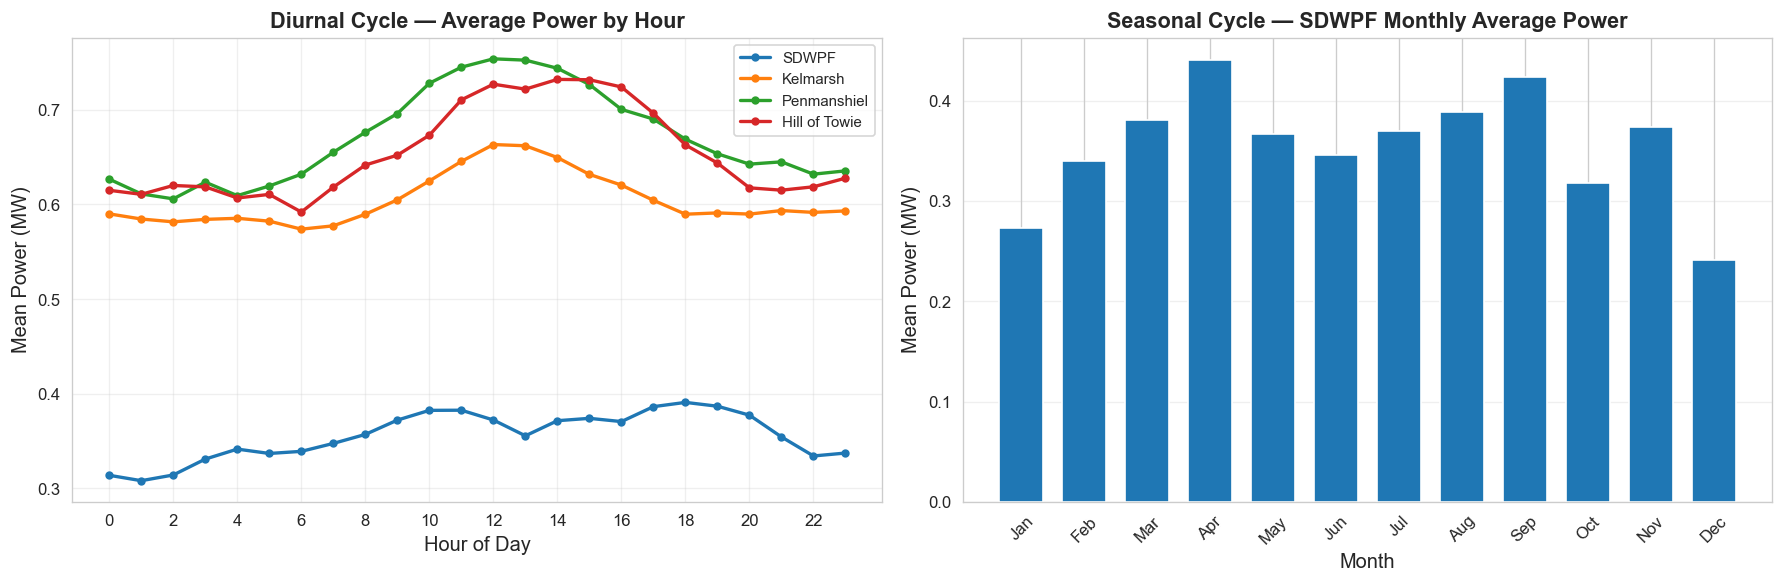

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Diurnal cycle
for name, df in data.items():
    hourly = df.groupby(df["time"].dt.hour)["power"].mean()
    ax1.plot(hourly.index, hourly.values, marker="o", markersize=4,
             color=COLORS[name], label=name, linewidth=2)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Mean Power (MW)")
ax1.set_title("Diurnal Cycle — Average Power by Hour", fontweight="bold")
ax1.set_xticks(range(0, 24, 2))
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# Seasonal cycle (SDWPF only)
sdwpf = data["SDWPF"]
monthly = sdwpf.groupby(sdwpf["time"].dt.month)["power"].mean()
ax2.bar(monthly.index, monthly.values, color=COLORS["SDWPF"], edgecolor="white", width=0.7)
ax2.set_xlabel("Month")
ax2.set_ylabel("Mean Power (MW)")
ax2.set_title("Seasonal Cycle — SDWPF Monthly Average Power", fontweight="bold")
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                      "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
ax2.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()


## 7. Dataset Comparison — Descriptive Statistics

Mean, standard deviation, minimum, and maximum for each feature across all four datasets (suitable for paper tables).

In [8]:
stats_records = []
for name, df in data.items():
    for feat in FEATURES:
        col = df[feat].dropna()
        stats_records.append({
            "Dataset":  name,
            "Feature":  FEATURE_LABELS[feat],
            "Mean":     col.mean(),
            "Std":      col.std(),
            "Min":      col.min(),
            "Max":      col.max(),
        })

stats_df = pd.DataFrame(stats_records)

# Pivot for a cleaner view: rows = Feature, columns = (Stat, Dataset)
pivot = stats_df.pivot_table(
    index="Feature",
    columns="Dataset",
    values=["Mean", "Std", "Min", "Max"],
)

# Reorder columns for consistency
col_order = ["SDWPF", "Kelmarsh", "Penmanshiel", "Hill of Towie"]
pivot = pivot.reindex(columns=col_order, level=1)

# Round for readability
pivot = pivot.round(3)
display(pivot)


Max                                       \
Dataset                  SDWPF   Kelmarsh Penmanshiel Hill of Towie   
Feature                                                               
Air Density (kg/m³)      1.204      1.304       1.261         1.251   
Power (MW)               1.500      2.050       2.050         2.300   
Pressure (Pa)        87187.703  99713.700   98945.323     97190.435   
Temperature (K)        310.812    310.271     301.141       297.933   
Wind Direction (°)     191.948    358.483     357.743       359.900   
Wind Speed (m/s)        39.850     22.743      25.442        24.692   

                          Mean                                       \
Dataset                  SDWPF   Kelmarsh Penmanshiel Hill of Towie   
Feature                                                               
Air Density (kg/m³)      1.051      1.219       1.218         1.207   
Power (MW)               0.356      0.604       0.670         0.654   
Pressure (Pa)        85345.177  99579.530   98945.323     97190.435   
Temperature (K)        283.692    284.633     283.064       280.569   
Wind Direction (°)       0.747    200.044     196.655       209.381   
Wind Speed (m/s)         5.010      6.109       7.399         6.837   

                           Min                                           Std  \
Dataset                  SDWPF   Kelmarsh Penmanshiel Hill of Towie    SDWPF   
Feature                                                                        
Air Density (kg/m³)      0.942      1.117       1.145         1.136    0.057   
Power (MW)               0.000      0.000       0.000         0.000    0.414   
Pressure (Pa)        83933.328  99453.095   98945.323     97190.435  611.496   
Temperature (K)        250.848    266.314     273.340       270.628   13.678   
Wind Direction (°)    -179.970      1.041       1.659         0.000   26.535   
Wind Speed (m/s)         0.000      0.145       0.308         0.000    3.405   

                                                        
Dataset             Kelmarsh Penmanshiel Hill of Towie  
Feature                                                 
Air Density (kg/m³)    0.025       0.020         0.020  
Power (MW)             0.598       0.693         0.710  
Pressure (Pa)         87.952       0.000         0.000  
Temperature (K)        5.922       4.636         4.672  
Wind Direction (°)    88.601      77.706        80.758  
Wind Speed (m/s)       2.650       4.118         3.665

---
### Key Takeaways

1. **Power curves** show the expected cubic-then-flat shape; SDWPF turbines have lower rated power than UK sites.
2. **Wind direction** varies by geography — SDWPF is dominated by westerlies while UK sites show more varied patterns.
3. **Distribution shift** is clear in temperature (Chinese continental vs. UK maritime) and pressure, motivating the need for a foundation model that generalises.
4. **Missing/zero data** is significant in the power column, likely due to curtailment and maintenance shutdowns.
5. **Temporal patterns** reveal a weak diurnal signal and stronger seasonal variation (wind is weather-driven, not demand-driven).
